In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_excel("/content/online_retail_II.xlsx", engine="openpyxl")

In [3]:
df.shape

(525461, 8)

In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [6]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


In [7]:
df.duplicated().sum()

np.int64(6865)

In [8]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,525461.0,10.337667,-9600.0,1.0,3.0,10.0,19152.0,107.42411
InvoiceDate,525461,2010-06-28 11:37:36.845017856,2009-12-01 07:45:00,2010-03-21 12:20:00,2010-07-06 09:51:00,2010-10-15 12:45:00,2010-12-09 20:01:00,NaN
Price,525461.0,4.688834,-53594.36,1.25,2.1,4.21,25111.09,146.126914
Customer ID,417534.0,15360.645478,12346.0,13983.0,15311.0,16799.0,18287.0,1680.811316


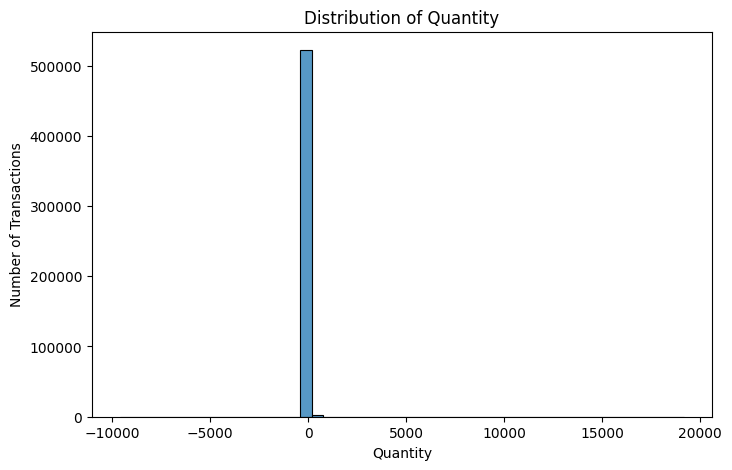

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Quantity", bins=50)
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Number of Transactions")
plt.show()

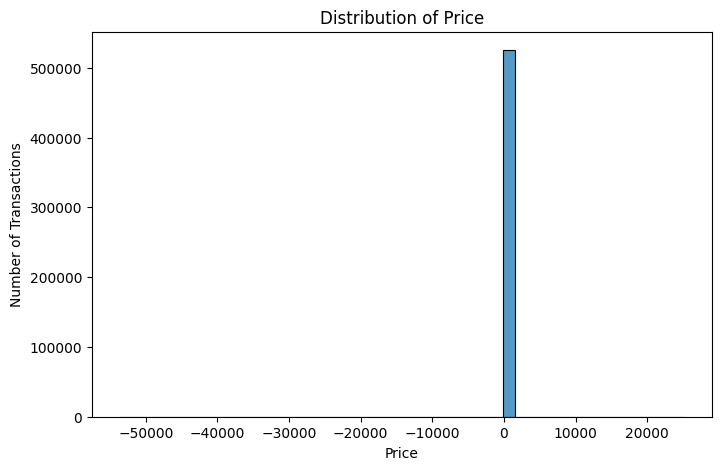

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Price", bins=50)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Number of Transactions")
plt.show()

In [11]:
df = df.drop_duplicates().copy()

print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 518596


In [12]:
print("Negative quantity:", (df["Quantity"] < 0).sum())
print("Zero quantity:", (df["Quantity"] == 0).sum())

print("Negative price:", (df["Price"] < 0).sum())
print("Zero price:", (df["Price"] == 0).sum())

Negative quantity: 12302
Zero quantity: 0
Negative price: 3
Zero price: 3681


In [13]:
df[df["Quantity"] < 0][
    ["Invoice", "StockCode", "Description", "Quantity",
     "InvoiceDate", "Price", "Customer ID", "Country"]
].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [14]:
print(
    "Cancelled invoices:",
    df["Invoice"].astype(str).str.startswith("C").sum()
)

Cancelled invoices: 10182


In [15]:
df = df[~df["Invoice"].astype(str).str.startswith("C")].copy()

In [16]:
print("Rows after removing cancellations:", len(df))
print("Cancelled invoices remaining:",
      df["Invoice"].astype(str).str.startswith("C").sum())

Rows after removing cancellations: 508414
Cancelled invoices remaining: 0


In [17]:
print("Total rows:", len(df))
print("Missing Customer IDs:", df["Customer ID"].isnull().sum())
print(
    "Missing percentage:",
    round(df["Customer ID"].isnull().mean() * 100, 2),
    "%"
)

Total rows: 508414
Missing Customer IDs: 107467
Missing percentage: 21.14 %


In [18]:
missing_customer = df[df["Customer ID"].isnull()].copy()

missing_customer.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom


In [19]:
missing_customer[["Invoice", "StockCode", "Quantity", "Price", "Country"]].head(20)

,Invoice,StockCode,Quantity,Price,Country
263,489464,21733,-96,0.00,United Kingdom
283,489463,71477,-240,0.00,United Kingdom
284,489467,85123A,-192,0.00,United Kingdom
470,489521,21646,-50,0.00,United Kingdom
577,489525,85226C,1,0.55,United Kingdom
578,489525,85227,1,0.85,United Kingdom
1055,489548,22271,1,2.95,United Kingdom
1056,489548,22254,12,1.25,United Kingdom
1057,489548,22273,3,2.95,United Kingdom
1058,489548,22195,1,1.65,United Kingdom


In [20]:
print("Missing Customer ID rows:", len(missing_customer))
print("Unique invoices:", missing_customer["Invoice"].nunique())
print("Unique products:", missing_customer["StockCode"].nunique())

Missing Customer ID rows: 107467
Unique invoices: 5009
Unique products: 4405


In [21]:
df_clean = df.dropna(subset=["Customer ID"]).copy()

print("Rows after removing missing Customer ID:", len(df_clean))
print("Missing Customer IDs:", df_clean["Customer ID"].isnull().sum())

Rows after removing missing Customer ID: 400947
Missing Customer IDs: 0


In [22]:
print("Zero-price rows:", (df_clean["Price"] == 0).sum())

Zero-price rows: 31


In [23]:
print("Negative-price rows:", (df_clean["Price"] < 0).sum())

Negative-price rows: 0


In [24]:
df_clean[df_clean["Price"] == 0][
    ["Invoice", "StockCode", "Description",
     "Quantity", "InvoiceDate", "Customer ID", "Country"]
].head(31)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,16126.0,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,15658.0,United Kingdom
16107,490727,M,Manual,1,2009-12-07 16:38:00,17231.0,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,14108.0,United Kingdom
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,14108.0,United Kingdom
32916,492079,85042,ANTIQUE LILY FAIRY LIGHTS,8,2009-12-15 13:49:00,15070.0,United Kingdom
40101,492760,21143,ANTIQUE GLASS HEART DECORATION,12,2009-12-18 14:22:00,18071.0,United Kingdom
47126,493761,79320,FLAMINGO LIGHTS,24,2010-01-06 14:54:00,14258.0,United Kingdom
48342,493899,22355,"CHARLOTTE BAG , SUKI DESIGN",10,2010-01-08 10:43:00,12417.0,Belgium
57619,494607,21533,RETRO SPOT LARGE MILK JUG,12,2010-01-15 12:43:00,16858.0,United Kingdom


In [25]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


In [26]:
print("Negative quantity:", (df_clean["Quantity"] < 0).sum())

Negative quantity: 0


In [27]:
df_clean["TotalAmount"] = df_clean["Quantity"] * df_clean["Price"]

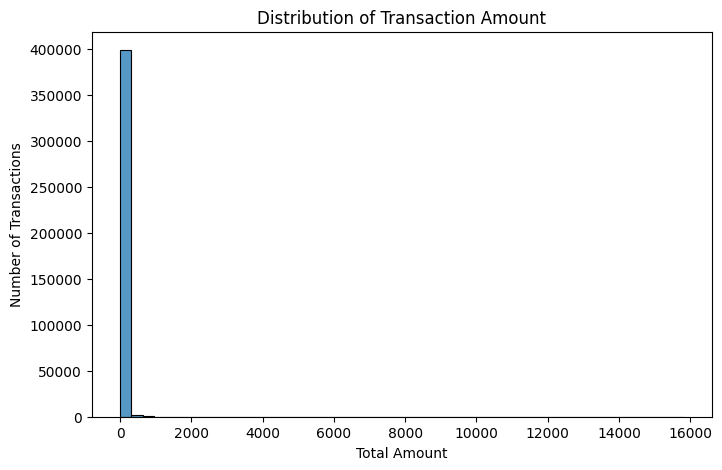

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(data=df_clean, x="TotalAmount", bins=50)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Total Amount")
plt.ylabel("Number of Transactions")
plt.show()

In [29]:
df_clean[["Quantity", "Price", "TotalAmount"]].head()

,Quantity,Price,TotalAmount
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [30]:
customer_df = df_clean.groupby("Customer ID").agg(
    Recency=("InvoiceDate",
             lambda x: (df_clean["InvoiceDate"].max() - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("TotalAmount", "sum"),
    TotalQuantity=("Quantity", "sum"),
    UniqueProducts=("StockCode", "nunique")
).reset_index()

In [31]:
customer_df.shape

(4314, 6)

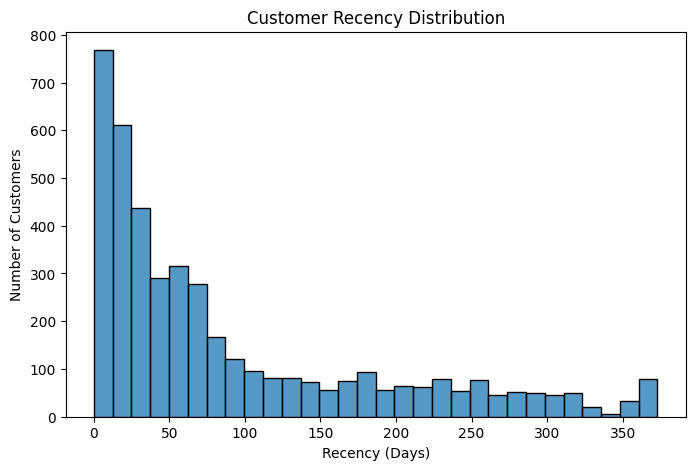

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(data=customer_df, x="Recency", bins=30)
plt.title("Customer Recency Distribution")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")
plt.show()

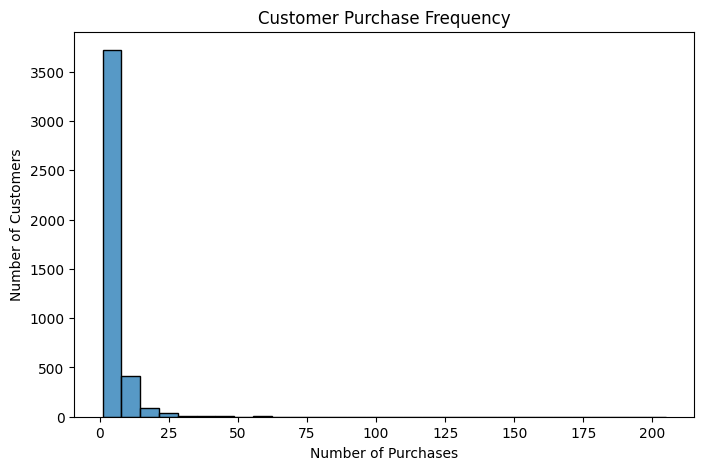

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(data=customer_df, x="Frequency", bins=30)
plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.show()

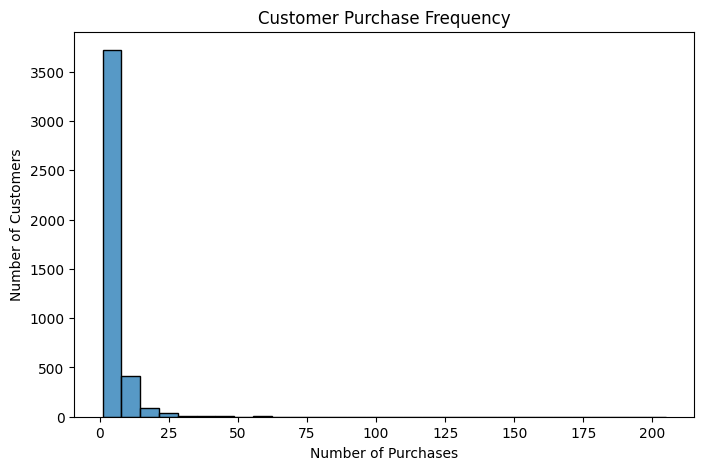

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(data=customer_df, x="Frequency", bins=30)
plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.show()

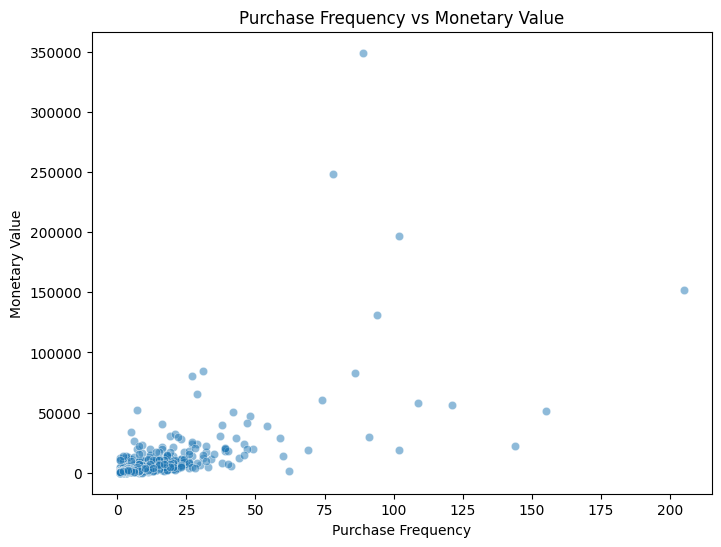

In [35]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=customer_df,
    x="Frequency",
    y="Monetary",
    alpha=0.5
)

plt.title("Purchase Frequency vs Monetary Value")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.show()

In [36]:
customer_df.isnull().sum()

,0
Customer ID,0
Recency,0
Frequency,0
Monetary,0
TotalQuantity,0
UniqueProducts,0


In [37]:
customer_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer ID,4314.0,15348.880389,1700.930104,12346.0,13883.250,15348.500,16833.7500,18287.00
Recency,4314.0,90.269124,96.943482,0.0,17.000,52.000,135.0000,373.00
Frequency,4314.0,4.454103,8.168658,1.0,1.000,2.000,5.0000,205.00
Monetary,4314.0,2039.460766,8909.797773,0.0,307.105,700.405,1713.2975,349164.35
TotalQuantity,4314.0,1279.658785,6457.213973,1.0,156.000,379.500,992.0000,220600.00
UniqueProducts,4314.0,63.618220,85.753098,1.0,17.000,38.000,79.0000,1741.00


In [38]:
features = customer_df[
    ["Recency", "Frequency", "Monetary",
     "TotalQuantity", "UniqueProducts"]
].copy()

In [39]:
features.head()

,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts
0,164,11,372.86,70,26
1,2,2,1323.32,828,70
2,73,1,222.16,373,20
3,42,3,2671.14,993,90
4,10,1,300.93,261,21


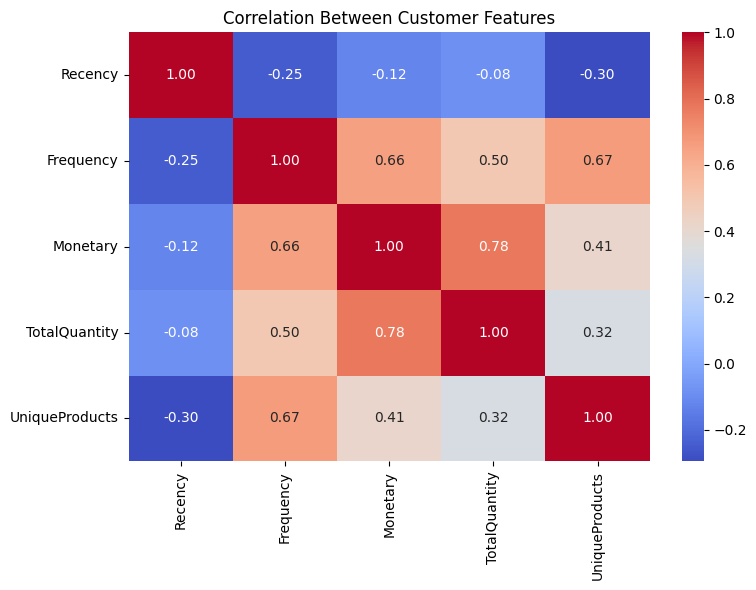

In [40]:
plt.figure(figsize=(8,6))

sns.heatmap(
    features.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Customer Features")
plt.tight_layout()
plt.show()

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(features)

In [42]:
X_scaled.shape

(4314, 5)

In [43]:
X_scaled[:5]

array([[ 0.76064344,  0.80143595, -0.18707428, -0.18735619, -0.43873144],
       [-0.91062704, -0.30046398, -0.08038609, -0.06995449,  0.07442903],
       [-0.17815665, -0.42289731, -0.2039902 , -0.14042649, -0.50870787],
       [-0.49796767, -0.17803066,  0.07090536, -0.04439872,  0.30768379],
       [-0.82809517, -0.42289731, -0.19514835, -0.15777344, -0.49704513]])

In [44]:
print("Original:")
print(features.head())

print("\nScaled:")
print(X_scaled[:5])

Original:
   Recency  Frequency  Monetary  TotalQuantity  UniqueProducts
0      164         11    372.86             70              26
1        2          2   1323.32            828              70
2       73          1    222.16            373              20
3       42          3   2671.14            993              90
4       10          1    300.93            261              21

Scaled:
[[ 0.76064344  0.80143595 -0.18707428 -0.18735619 -0.43873144]
 [-0.91062704 -0.30046398 -0.08038609 -0.06995449  0.07442903]
 [-0.17815665 -0.42289731 -0.2039902  -0.14042649 -0.50870787]
 [-0.49796767 -0.17803066  0.07090536 -0.04439872  0.30768379]
 [-0.82809517 -0.42289731 -0.19514835 -0.15777344 -0.49704513]]


In [45]:
customer_df.head()

,Customer ID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts
0,12346.0,164,11,372.86,70,26
1,12347.0,2,2,1323.32,828,70
2,12348.0,73,1,222.16,373,20
3,12349.0,42,3,2671.14,993,90
4,12351.0,10,1,300.93,261,21


In [46]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

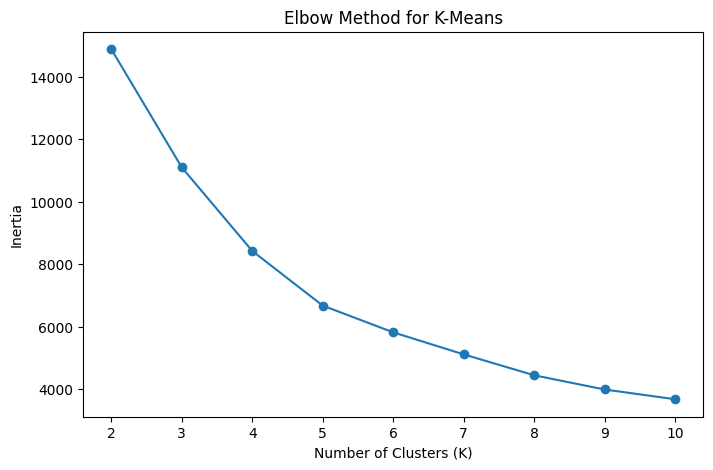

In [47]:
plt.figure(figsize=(8,5))
plt.plot(range(2, 11), inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

In [48]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

silhouette = silhouette_score(X_scaled, kmeans_labels)

print("K-Means Silhouette Score:", silhouette)

K-Means Silhouette Score: 0.5040000417782613


In [49]:
import numpy as np

print("Cluster sizes:")
print(np.bincount(kmeans_labels))

Cluster sizes:
[1018    6 2655   33  602]


In [50]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans_scores = []

for k in range(2, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    kmeans_scores.append(score)

    print(f"K-Means K={k}: {score:.4f}")

K-Means K=2: 0.9175
K-Means K=3: 0.4594
K-Means K=4: 0.5079
K-Means K=5: 0.5040
K-Means K=6: 0.5072
K-Means K=7: 0.4612
K-Means K=8: 0.4613


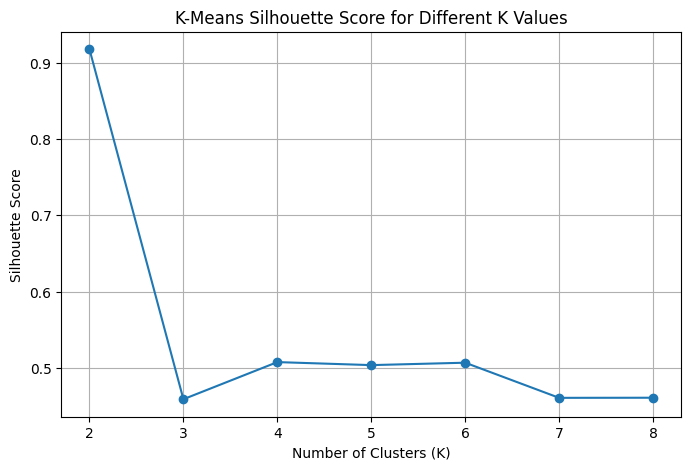

In [51]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2, 9),
    kmeans_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Score for Different K Values")
plt.xticks(range(2, 9))
plt.grid(True)

plt.show()

In [52]:
kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

final_labels = kmeans_final.fit_predict(X_scaled)

customer_df["Cluster"] = final_labels

print(customer_df["Cluster"].value_counts().sort_index())

Cluster
0    4296
1      18
Name: count, dtype: int64


In [53]:
cluster_profile = customer_df.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary",
     "TotalQuantity", "UniqueProducts"]
].mean()

cluster_profile

,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts
Cluster,,,,,
0,90.567737,4.104981,1638.110983,997.402933,61.327281
1,19.000000,87.777778,97828.275556,68644.722222,610.388889


In [54]:
features_log = features.copy()

features_log["Recency"] = np.log1p(features_log["Recency"])
features_log["Frequency"] = np.log1p(features_log["Frequency"])
features_log["Monetary"] = np.log1p(features_log["Monetary"])
features_log["TotalQuantity"] = np.log1p(features_log["TotalQuantity"])
features_log["UniqueProducts"] = np.log1p(features_log["UniqueProducts"])

In [55]:
scaler_log = StandardScaler()
X_scaled_log = scaler_log.fit_transform(features_log)

print(X_scaled_log.shape)

(4314, 5)


In [56]:
kmeans_log_scores = []

for k in range(2, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled_log)

    score = silhouette_score(X_scaled_log, labels)

    kmeans_log_scores.append(score)

    print(f"K-Means Log K={k}: {score:.4f}")

K-Means Log K=2: 0.3915
K-Means Log K=3: 0.2909
K-Means Log K=4: 0.2403
K-Means Log K=5: 0.2437
K-Means Log K=6: 0.2310
K-Means Log K=7: 0.2308
K-Means Log K=8: 0.2252


In [57]:
for k in [3, 4, 5, 6]:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print("\nK =", k)
    print("Silhouette:", round(score, 4))
    print("Cluster sizes:", np.bincount(labels))


K = 3
Silhouette: 0.4594
Cluster sizes: [1095   18 3201]

K = 4
Silhouette: 0.5079
Cluster sizes: [ 224 3042 1042    6]

K = 5
Silhouette: 0.504
Cluster sizes: [1018    6 2655   33  602]

K = 6
Silhouette: 0.5072
Cluster sizes: [1019 2695    5  576    6   13]


In [58]:
kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels_3 = kmeans_3.fit_predict(X_scaled)

customer_df["Cluster_3"] = labels_3

cluster_profile_3 = customer_df.groupby("Cluster_3")[
    ["Recency", "Frequency", "Monetary",
     "TotalQuantity", "UniqueProducts"]
].mean()

cluster_profile_3

,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts
Cluster_3,,,,,
0,236.923288,1.624658,543.738150,299.453881,25.075799
1,19.000000,87.777778,97828.275556,68644.722222,610.388889
2,40.502343,4.953452,2012.474699,1236.157763,73.728210


In [59]:
kmeans_3_silhouette = silhouette_score(
    X_scaled,
    labels_3
)

print("K-Means K=3 Silhouette:",
      round(kmeans_3_silhouette, 4))

print("\nCluster sizes:")
print(pd.Series(labels_3).value_counts().sort_index())

K-Means K=3 Silhouette: 0.4594

Cluster sizes:
0    1095
1      18
2    3201
Name: count, dtype: int64


In [60]:
cluster_counts = customer_df["Cluster_3"].value_counts().sort_index()

cluster_percent = (
    cluster_counts / len(customer_df) * 100
).round(2)

print(cluster_counts)
print(cluster_percent)

Cluster_3
0    1095
1      18
2    3201
Name: count, dtype: int64
Cluster_3
0    25.38
1     0.42
2    74.20
Name: count, dtype: float64


In [61]:
cluster_profile_3

,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts
Cluster_3,,,,,
0,236.923288,1.624658,543.738150,299.453881,25.075799
1,19.000000,87.777778,97828.275556,68644.722222,610.388889
2,40.502343,4.953452,2012.474699,1236.157763,73.728210


In [62]:
cluster_1_customers = customer_df[
    customer_df["Cluster_3"] == 1
]

cluster_1_customers[
    ["Customer ID", "Recency", "Frequency",
     "Monetary", "TotalQuantity", "UniqueProducts"]
]

,Customer ID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts
251,12748.0,0,144,22457.90,13110,1343
506,13089.0,3,109,57885.45,29130,474
939,13694.0,8,94,131443.19,125893,654
1091,13902.0,267,5,34095.26,220600,58
1270,14156.0,6,102,196549.74,108105,1094
1379,14298.0,10,38,39667.19,41929,712
1607,14606.0,1,102,18482.10,9287,1086
1638,14646.0,9,78,248396.50,170342,606
1842,14911.0,0,205,152121.22,69709,1741
1953,15061.0,2,86,83284.38,51791,116


In [63]:
customer_df["KMeans_Cluster"] = labels_3

In [64]:
cluster_summary = customer_df.groupby("KMeans_Cluster")[
    ["Recency", "Frequency", "Monetary",
     "TotalQuantity", "UniqueProducts"]
].mean()

cluster_summary

,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts
KMeans_Cluster,,,,,
0,236.923288,1.624658,543.738150,299.453881,25.075799
1,19.000000,87.777778,97828.275556,68644.722222,610.388889
2,40.502343,4.953452,2012.474699,1236.157763,73.728210


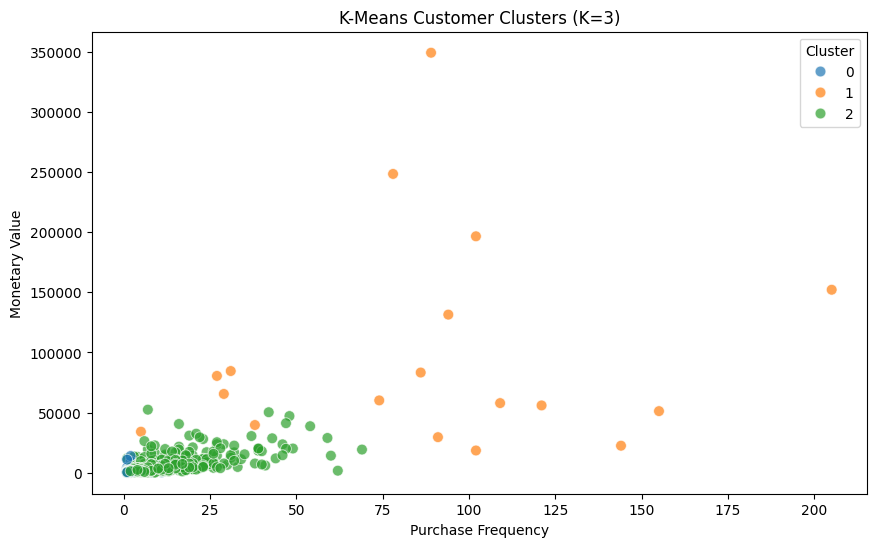

In [65]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=customer_df,
    x="Frequency",
    y="Monetary",
    hue="KMeans_Cluster",
    palette="tab10",
    s=60,
    alpha=0.7
)

plt.title("K-Means Customer Clusters (K=3)")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")
plt.show()

In [66]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

print("DBSCAN Cluster Labels:")
print(np.unique(dbscan_labels))

print("Cluster Sizes:")
print(np.bincount(dbscan_labels[dbscan_labels >= 0]))

DBSCAN Cluster Labels:
[-1  0]
Cluster Sizes:
[4132]


In [67]:
print("DBSCAN cluster counts:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN cluster counts:
-1     182
 0    4132
Name: count, dtype: int64


In [68]:
for eps in [0.3, 0.5, 0.7, 1.0, 1.2]:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    print(
        f"eps={eps} | clusters={n_clusters} | noise={n_noise}"
    )

eps=0.3 | clusters=5 | noise=380
eps=0.5 | clusters=1 | noise=182
eps=0.7 | clusters=2 | noise=102
eps=1.0 | clusters=1 | noise=65
eps=1.2 | clusters=2 | noise=56


In [69]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

for eps in [0.3, 0.5, 0.7, 1.0, 1.2]:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(X_scaled)
    mask = labels != -1

    n_clusters = len(set(labels[mask]))
    n_noise = (labels == -1).sum()

    if n_clusters >= 2:
        score = silhouette_score(
            X_scaled[mask],
            labels[mask]
        )
        print(
            f"eps={eps} | clusters={n_clusters} | "
            f"noise={n_noise} | silhouette={score:.4f}"
        )
    else:
        print(
            f"eps={eps} | clusters={n_clusters} | "
            f"noise={n_noise} | silhouette=Not available"
        )

eps=0.3 | clusters=5 | noise=380 | silhouette=0.2915
eps=0.5 | clusters=1 | noise=182 | silhouette=Not available
eps=0.7 | clusters=2 | noise=102 | silhouette=0.7009
eps=1.0 | clusters=1 | noise=65 | silhouette=Not available
eps=1.2 | clusters=2 | noise=56 | silhouette=0.7094


In [70]:
dbscan = DBSCAN(
    eps=1.2,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

print("DBSCAN Silhouette:",
      round(silhouette_score(
          X_scaled[dbscan_labels != -1],
          dbscan_labels[dbscan_labels != -1]
      ), 4))

print("\nDBSCAN cluster counts:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN Silhouette: 0.7094

DBSCAN cluster counts:
-1      56
 0    4254
 1       4
Name: count, dtype: int64


In [71]:
dbscan_silhouette = silhouette_score(
    X_scaled[dbscan_labels != -1],
    dbscan_labels[dbscan_labels != -1]
)

print("\nDBSCAN Silhouette:",
      round(dbscan_silhouette, 4))

print("\nDBSCAN Cluster sizes:")
print(pd.Series(dbscan_labels).value_counts().sort_index())


DBSCAN Silhouette: 0.7094

DBSCAN Cluster sizes:
-1      56
 0    4254
 1       4
Name: count, dtype: int64


In [72]:
dbscan_special = customer_df[
    dbscan_labels != 0
][[
    "Customer ID",
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "UniqueProducts"
]].copy()

dbscan_special["DBSCAN_Cluster"] = dbscan_labels[
    dbscan_labels != 0
]

dbscan_special.sort_values(
    "Monetary",
    ascending=False
).head(20)

,Customer ID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,DBSCAN_Cluster
4185,18102.0,0,89,349164.35,124216,281,-1
1638,14646.0,9,78,248396.50,170342,606,-1
1270,14156.0,6,102,196549.74,108105,1094,-1
1842,14911.0,0,205,152121.22,69709,1741,-1
939,13694.0,8,94,131443.19,125893,654,-1
3746,17511.0,2,31,84541.17,55107,423,-1
1953,15061.0,2,86,83284.38,51791,116,-1
3130,16684.0,14,27,80489.21,54555,124,-1
3179,16754.0,7,29,65500.07,63551,38,-1
4067,17949.0,6,74,60117.60,30112,34,-1


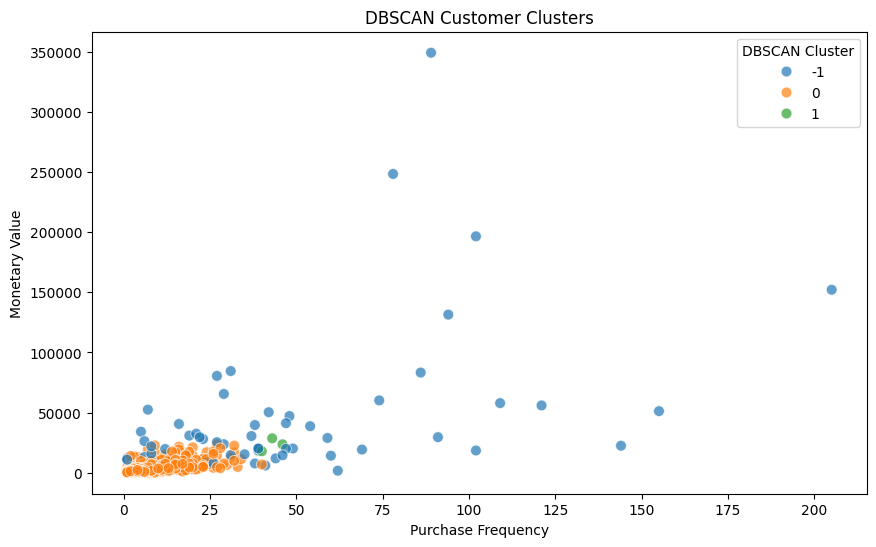

In [73]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=customer_df["Frequency"],
    y=customer_df["Monetary"],
    hue=dbscan_labels,
    palette="tab10",
    s=60,
    alpha=0.7
)

plt.title("DBSCAN Customer Clusters")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.legend(title="DBSCAN Cluster")
plt.show()

In [74]:
print("===== CLUSTERING COMPARISON =====")

print("\nK-Means:")
print("Silhouette:", round(silhouette, 4))
print("Cluster sizes:")
print(pd.Series(labels_3).value_counts().sort_index())

print("\nDBSCAN:")
print("Silhouette:", round(dbscan_silhouette, 4))
print("Cluster sizes:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

===== CLUSTERING COMPARISON =====

K-Means:
Silhouette: 0.504
Cluster sizes:
0    1095
1      18
2    3201
Name: count, dtype: int64

DBSCAN:
Silhouette: 0.7094
Cluster sizes:
-1      56
 0    4254
 1       4
Name: count, dtype: int64


In [75]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)

print("Explained variance ratio:",
      pca.explained_variance_ratio_)

print("Total explained variance:",
      round(pca.explained_variance_ratio_.sum(), 4))

Original shape: (4314, 5)
PCA shape: (4314, 2)
Explained variance ratio: [0.55203606 0.21330052]
Total explained variance: 0.7653


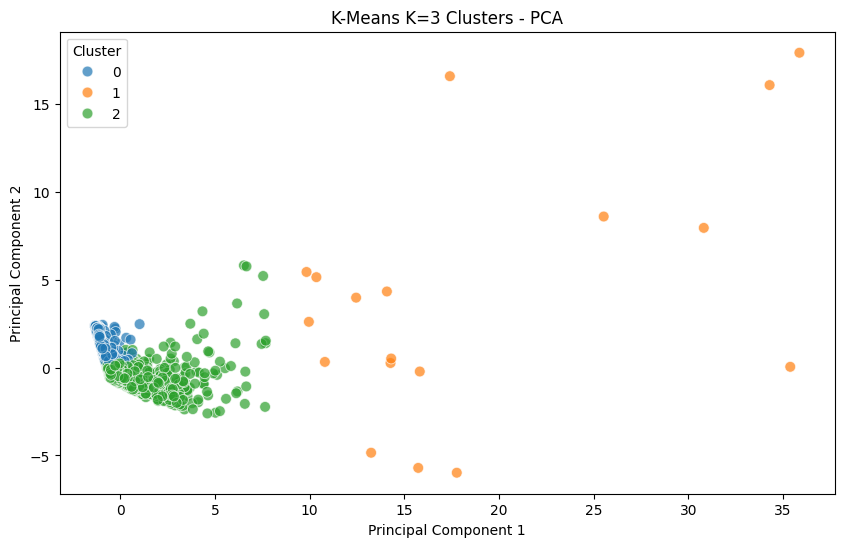

In [76]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels_3,
    palette="tab10",
    s=60,
    alpha=0.7
)

plt.title("K-Means K=3 Clusters - PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

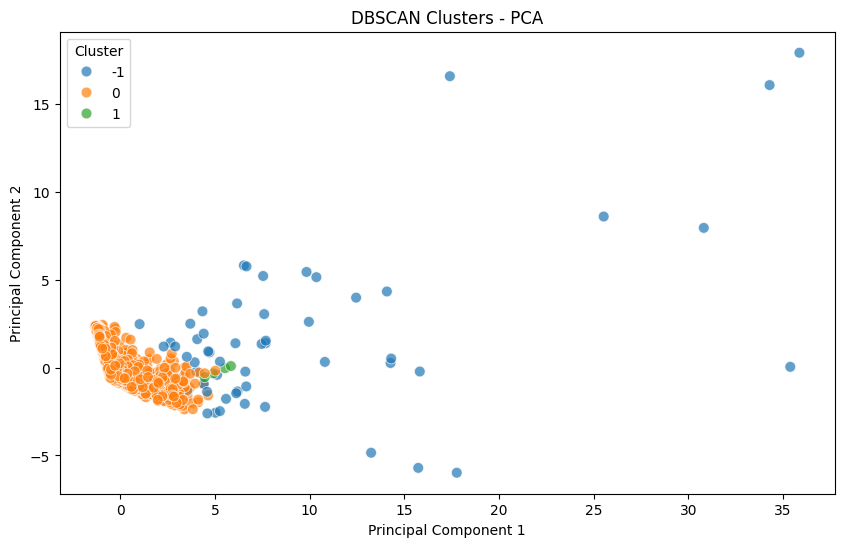

In [77]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=dbscan_labels,
    palette="tab10",
    s=60,
    alpha=0.7
)

plt.title("DBSCAN Clusters - PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

In [78]:
# Check customer-level features
customer_df[
    ["Customer ID",
     "Recency",
     "Frequency",
     "Monetary",
     "TotalQuantity",
     "UniqueProducts"]
].head()

,Customer ID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts
0,12346.0,164,11,372.86,70,26
1,12347.0,2,2,1323.32,828,70
2,12348.0,73,1,222.16,373,20
3,12349.0,42,3,2671.14,993,90
4,12351.0,10,1,300.93,261,21


starting supriveed learing part

In [79]:
print("Dataset date range:")
print(df_clean["InvoiceDate"].min())
print(df_clean["InvoiceDate"].max())

print("\nRecency range:")
print(customer_df["Recency"].min())
print(customer_df["Recency"].max())

print("\nRecency statistics:")
print(customer_df["Recency"].describe())

Dataset date range:
2009-12-01 07:45:00
2010-12-09 20:01:00

Recency range:
0
373

Recency statistics:
count    4314.000000
mean       90.269124
std        96.943482
min         0.000000
25%        17.000000
50%        52.000000
75%       135.000000
max       373.000000
Name: Recency, dtype: float64


In [80]:
# Check the available date range
print("Start:", df_clean["InvoiceDate"].min())
print("End:", df_clean["InvoiceDate"].max())

# Choose a cutoff date
cutoff_date = pd.Timestamp("2010-09-10")

print("Cutoff date:", cutoff_date)

print("\nFeature period:")
print(df_clean[df_clean["InvoiceDate"] <= cutoff_date]["InvoiceDate"].max())

print("\nFuture period:")
print(df_clean[df_clean["InvoiceDate"] > cutoff_date]["InvoiceDate"].min())

Start: 2009-12-01 07:45:00
End: 2010-12-09 20:01:00
Cutoff date: 2010-09-10 00:00:00

Feature period:
2010-09-09 20:03:00

Future period:
2010-09-10 08:50:00


In [81]:
# Future transactions
future_data = df_clean[
    df_clean["InvoiceDate"] >= cutoff_date
].copy()

# Customers who made at least one purchase in the future period
future_customers = future_data["Customer ID"].dropna().unique()

print("Customers with future purchase:",
      len(future_customers))

Customers with future purchase: 2885


In [82]:
# Create Churn target
customer_df["Churn"] = (
    ~customer_df["Customer ID"].isin(future_customers)
).astype(int)

print("Churn counts:")
print(customer_df["Churn"].value_counts())

Churn counts:
Churn
0    2885
1    1429
Name: count, dtype: int64


In [83]:
print("\nChurn percentage:")
print(
    customer_df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


Churn percentage:
Churn
0    66.88
1    33.12
Name: proportion, dtype: float64


In [84]:
# Features
X = customer_df[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "TotalQuantity",
        "UniqueProducts"
    ]
].copy()

# Target
y = customer_df["Churn"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4314, 5)
y shape: (4314,)


In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3451, 5)
Testing data: (863, 5)


In [86]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
logreg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logreg.fit(X_train_scaled, y_train)

# Churn probability
y_prob = logreg.predict_proba(X_test_scaled)[:, 1]

# Decision threshold = 0.5
threshold = 0.5

y_pred = (y_prob >= threshold).astype(int)

print("Threshold:", threshold)
print("Predictions:", y_pred[:10])

Threshold: 0.5
Predictions: [0 0 0 0 0 0 1 0 0 1]


In [87]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9965
Precision: 1.0
Recall: 0.9895
F1 Score: 0.9947

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       577
           1       1.00      0.99      0.99       286

    accuracy                           1.00       863
   macro avg       1.00      0.99      1.00       863
weighted avg       1.00      1.00      1.00       863


Confusion Matrix:
[[577   0]
 [  3 283]]


In [88]:
for threshold in [0.3, 0.5, 0.7, 0.9]:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    print(
        "Threshold:", threshold,
        "| Predicted Churn:", y_pred_threshold.sum()
    )

Threshold: 0.3 | Predicted Churn: 292
Threshold: 0.5 | Predicted Churn: 283
Threshold: 0.7 | Predicted Churn: 271
Threshold: 0.9 | Predicted Churn: 256


In [89]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for threshold in [0.3, 0.5, 0.7, 0.9]:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    print("\nThreshold:", threshold)
    print("Predicted Churn:", y_pred_threshold.sum())
    print("Accuracy:", round(accuracy_score(y_test, y_pred_threshold), 4))
    print("Precision:", round(precision_score(y_test, y_pred_threshold, zero_division=0), 4))
    print("Recall:", round(recall_score(y_test, y_pred_threshold, zero_division=0), 4))
    print("F1:", round(f1_score(y_test, y_pred_threshold, zero_division=0), 4))


Threshold: 0.3
Predicted Churn: 292
Accuracy: 0.993
Precision: 0.9795
Recall: 1.0
F1: 0.9896

Threshold: 0.5
Predicted Churn: 283
Accuracy: 0.9965
Precision: 1.0
Recall: 0.9895
F1: 0.9947

Threshold: 0.7
Predicted Churn: 271
Accuracy: 0.9826
Precision: 1.0
Recall: 0.9476
F1: 0.9731

Threshold: 0.9
Predicted Churn: 256
Accuracy: 0.9652
Precision: 1.0
Recall: 0.8951
F1: 0.9446


In [90]:
# Overfitting Check

# Training predictions
y_train_prob = logreg.predict_proba(X_train_scaled)[:, 1]

y_train_pred = (y_train_prob >= 0.5).astype(int)

# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_pred)

# Accuracy gap
accuracy_gap = train_accuracy - test_accuracy

print("Training Accuracy:", round(train_accuracy, 4))
print("Testing Accuracy :", round(test_accuracy, 4))
print("Accuracy Gap     :", round(accuracy_gap, 4))

Training Accuracy: 0.9925
Testing Accuracy : 0.9965
Accuracy Gap     : -0.0041


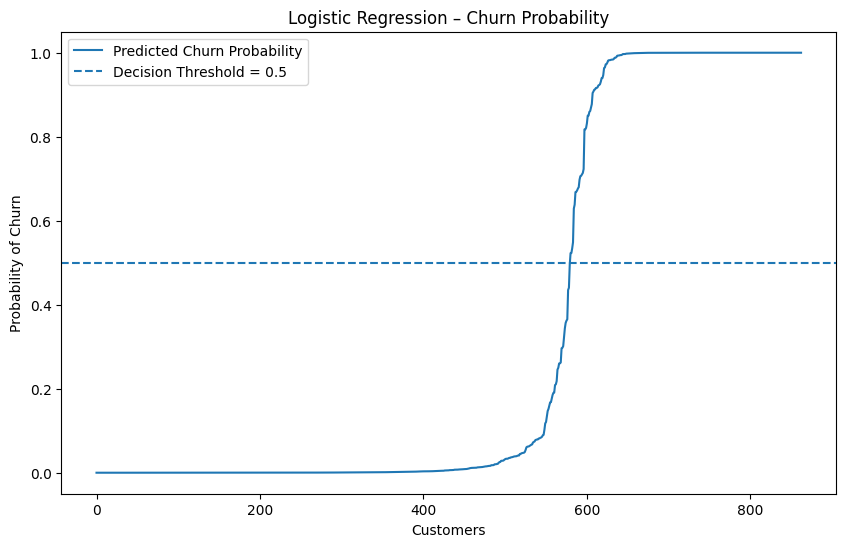

In [91]:
import numpy as np
import matplotlib.pyplot as plt

y_prob = logreg.predict_proba(X_test_scaled)[:, 1]

order = np.argsort(y_prob)

plt.figure(figsize=(10, 6))

plt.plot(
    np.arange(len(y_prob)),
    y_prob[order],
    label="Predicted Churn Probability"
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="Decision Threshold = 0.5"
)

plt.xlabel("Customers")
plt.ylabel("Probability of Churn")
plt.title("Logistic Regression – Churn Probability")
plt.legend()
plt.show()

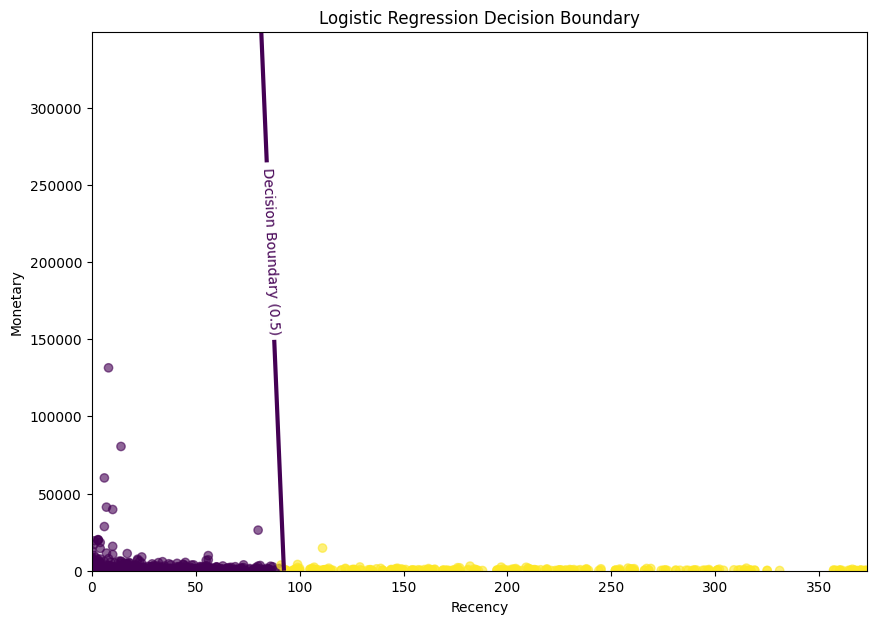

In [92]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
feature_x = "Recency"
feature_y = "Monetary"

x_min = X[feature_x].min()
x_max = X[feature_x].max()

y_min = X[feature_y].min()
y_max = X[feature_y].max()

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = pd.DataFrame({
    "Recency": xx.ravel(),
    "Frequency": X["Frequency"].mean(),
    "Monetary": yy.ravel(),
    "TotalQuantity": X["TotalQuantity"].mean(),
    "UniqueProducts": X["UniqueProducts"].mean()
})

grid_scaled = scaler.transform(grid)

probability = logreg.predict_proba(grid_scaled)[:, 1]

probability = probability.reshape(xx.shape)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_test["Recency"],
    X_test["Monetary"],
    c=y_test,
    alpha=0.6
)

boundary = plt.contour(
    xx,
    yy,
    probability,
    levels=[0.5],
    linewidths=3
)

plt.clabel(
    boundary,
    fmt={0.5: "Decision Boundary (0.5)"}
)

plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Logistic Regression Decision Boundary")

plt.show()

In [93]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train
dt_model.fit(X_train, y_train)

# Prediction
dt_pred = dt_model.predict(X_test)

print("Decision Tree Predictions:", dt_pred[:10])

Decision Tree Predictions: [0 0 0 0 0 0 1 0 0 1]


In [94]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Decision Tree Evaluation")

print("Accuracy:",
      round(accuracy_score(y_test, dt_pred), 4))

print("Precision:",
      round(precision_score(y_test, dt_pred, zero_division=0), 4))

print("Recall:",
      round(recall_score(y_test, dt_pred, zero_division=0), 4))

print("F1 Score:",
      round(f1_score(y_test, dt_pred, zero_division=0), 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        dt_pred,
        target_names=["Active", "Churn"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

Decision Tree Evaluation
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report:
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00       577
       Churn       1.00      1.00      1.00       286

    accuracy                           1.00       863
   macro avg       1.00      1.00      1.00       863
weighted avg       1.00      1.00      1.00       863


Confusion Matrix:
[[577   0]
 [  0 286]]


In [95]:
# Decision Tree Overfitting Check

# Training predictions
dt_train_pred = dt_model.predict(X_train)

# Training accuracy
dt_train_accuracy = accuracy_score(
    y_train,
    dt_train_pred
)

# Testing accuracy
dt_test_accuracy = accuracy_score(
    y_test,
    dt_pred
)

# Accuracy gap
dt_accuracy_gap = (
    dt_train_accuracy - dt_test_accuracy
)

print("Training Accuracy:",
      round(dt_train_accuracy, 4))

print("Testing Accuracy:",
      round(dt_test_accuracy, 4))

print("Accuracy Gap:",
      round(dt_accuracy_gap, 4))

Training Accuracy: 1.0
Testing Accuracy: 1.0
Accuracy Gap: 0.0


In [96]:
print("Tree depth:", dt_model.get_depth())
print("Number of leaves:", dt_model.get_n_leaves())

Tree depth: 1
Number of leaves: 2


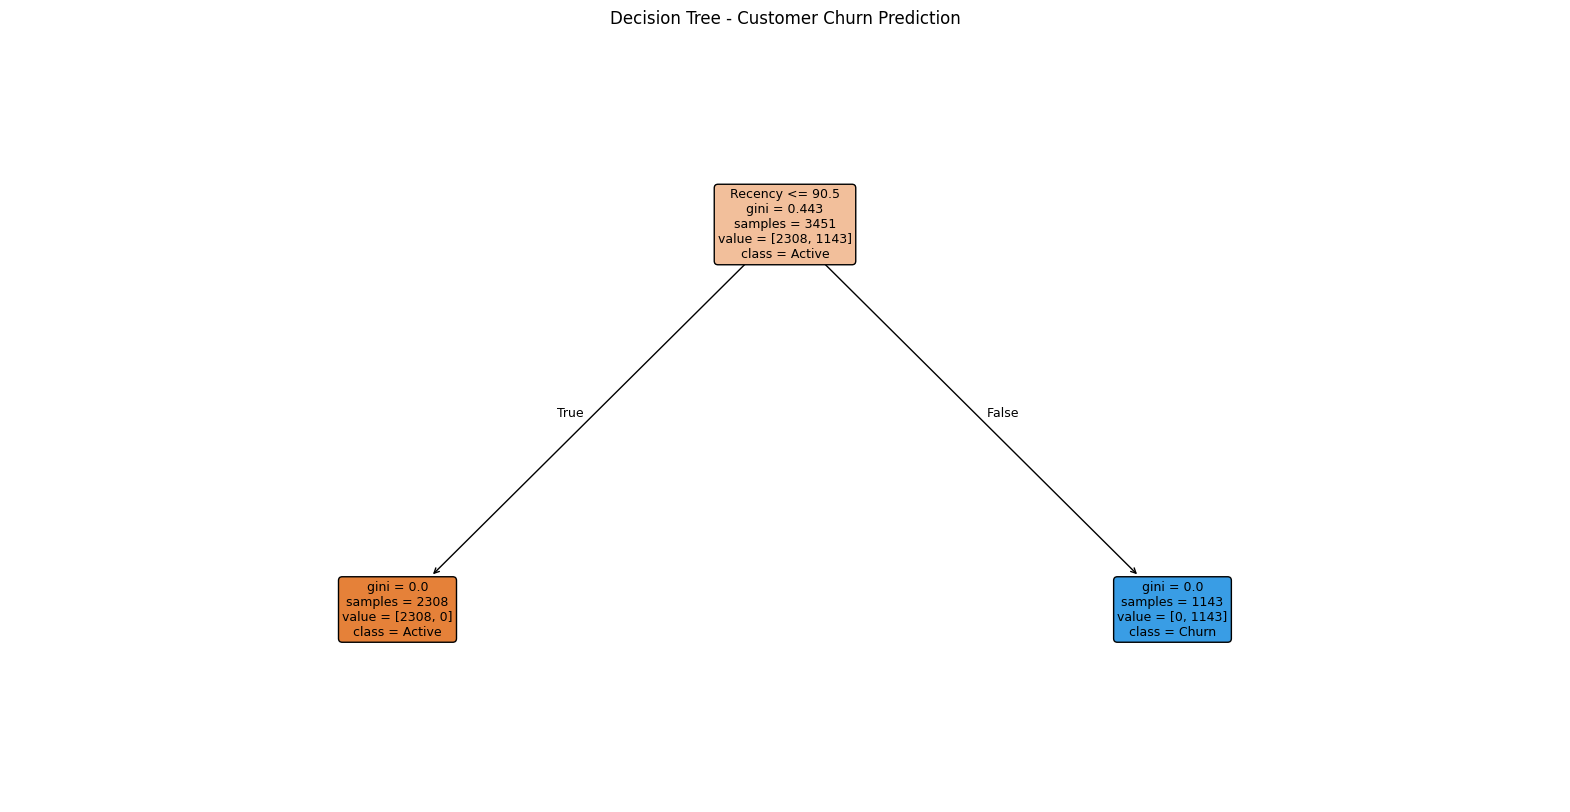

In [97]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["Active", "Churn"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree - Customer Churn Prediction")
plt.show()

In [98]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5
)

# Train model
rf_model.fit(X_train, y_train)

# Prediction
rf_pred = rf_model.predict(X_test)

print("Random Forest training completed.")
print("Predictions:", rf_pred[:10])

Random Forest training completed.
Predictions: [0 0 0 0 0 0 1 0 0 1]


In [99]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Random Forest Evaluation")

print("Accuracy:",
      round(accuracy_score(y_test, rf_pred), 4))

print("Precision:",
      round(precision_score(y_test, rf_pred, zero_division=0), 4))

print("Recall:",
      round(recall_score(y_test, rf_pred, zero_division=0), 4))

print("F1 Score:",
      round(f1_score(y_test, rf_pred, zero_division=0), 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Active", "Churn"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Evaluation
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report:
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00       577
       Churn       1.00      1.00      1.00       286

    accuracy                           1.00       863
   macro avg       1.00      1.00      1.00       863
weighted avg       1.00      1.00      1.00       863


Confusion Matrix:
[[577   0]
 [  0 286]]


In [100]:
# Random Forest Overfitting Check

rf_train_pred = rf_model.predict(X_train)

rf_train_accuracy = accuracy_score(
    y_train,
    rf_train_pred
)

rf_test_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_accuracy_gap = (
    rf_train_accuracy - rf_test_accuracy
)

print("Training Accuracy:",
      round(rf_train_accuracy, 4))

print("Testing Accuracy:",
      round(rf_test_accuracy, 4))

print("Accuracy Gap:",
      round(rf_accuracy_gap, 4))

Training Accuracy: 1.0
Testing Accuracy: 1.0
Accuracy Gap: 0.0


In [101]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print(feature_importance)

          Feature  Importance
0         Recency    0.881743
1       Frequency    0.048502
2        Monetary    0.037661
4  UniqueProducts    0.017904
3   TotalQuantity    0.014189


In [102]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9965,1.0,0.9895,0.9947
1,Decision Tree,1.0000,1.0,1.0000,1.0000
2,Random Forest,1.0000,1.0,1.0000,1.0000


In [103]:
from sklearn.metrics import confusion_matrix, classification_report

print("Decision Tree Classification Report:")
print(classification_report(y_test, dt_pred))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       577
           1       1.00      1.00      1.00       286

    accuracy                           1.00       863
   macro avg       1.00      1.00      1.00       863
weighted avg       1.00      1.00      1.00       863


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       577
           1       1.00      1.00      1.00       286

    accuracy                           1.00       863
   macro avg       1.00      1.00      1.00       863
weighted avg       1.00      1.00      1.00       863



In [104]:
print("Decision Tree")
print("Train Accuracy:", dt_model.score(X_train, y_train))
print("Test Accuracy :", dt_model.score(X_test, y_test))

print("\nRandom Forest")
print("Train Accuracy:", rf_model.score(X_train, y_train))
print("Test Accuracy :", rf_model.score(X_test, y_test))

Decision Tree
Train Accuracy: 1.0
Test Accuracy : 1.0

Random Forest
Train Accuracy: 1.0
Test Accuracy : 1.0


In [105]:
from sklearn.model_selection import cross_val_score

# Using the correct model variable names: dt_model and rf_model
dt_cv = cross_val_score(
    dt_model,
    X_scaled,
    y,
    cv=5,
    scoring="f1"
)

rf_cv = cross_val_score(
    rf_model,
    X_scaled,
    y,
    cv=5,
    scoring="f1"
)

print("Decision Tree CV F1:", dt_cv)
print("Decision Tree Mean CV F1:", round(dt_cv.mean(), 4))

print("\nRandom Forest CV F1:", rf_cv)
print("Random Forest Mean CV F1:", round(rf_cv.mean(), 4))

Decision Tree CV F1: [1. 1. 1. 1. 1.]
Decision Tree Mean CV F1: 1.0

Random Forest CV F1: [1. 1. 1. 1. 1.]
Random Forest Mean CV F1: 1.0


In [106]:
# Final Churn Model
final_churn_model = rf_model

print("Final churn model: Random Forest")
print("Cross-validation F1:", round(rf_cv.mean(), 4))

Final churn model: Random Forest
Cross-validation F1: 1.0


In [107]:
cluster_profile_3 = customer_df.groupby("Cluster_3")[
    ["Recency", "Frequency", "Monetary",
     "TotalQuantity", "UniqueProducts"]
].mean().round(2)

print("Final K-Means K=3 Cluster Profile:")
display(cluster_profile_3)

print("\nCluster Sizes:")
print(customer_df["Cluster_3"].value_counts().sort_index())

Final K-Means K=3 Cluster Profile:


,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts
Cluster_3,,,,,
0,236.92,1.62,543.74,299.45,25.08
1,19.00,87.78,97828.28,68644.72,610.39
2,40.50,4.95,2012.47,1236.16,73.73



Cluster Sizes:
Cluster_3
0    1095
1      18
2    3201
Name: count, dtype: int64


In [110]:
import numpy as np
import pandas as pd

cluster_names = {
    0: "Inactive / Low-Value Customer",
    1: "VIP / High-Value Customer",
    2: "Regular / Active Customer"
}


def predict_new_customer(
    recency,
    frequency,
    monetary,
    total_quantity,
    unique_products
):

    # New customer data
    new_customer = pd.DataFrame({
        "Recency": [recency],
        "Frequency": [frequency],
        "Monetary": [monetary],
        "TotalQuantity": [total_quantity],
        "UniqueProducts": [unique_products]
    })

    # Same scaler used during training
    new_customer_scaled = scaler.transform(new_customer)

    # K-Means clustering
    cluster = kmeans_3.predict(new_customer_scaled)[0]

    # Cluster business meaning
    segment = cluster_names[int(cluster)]

    # DataFrame with feature names for Random Forest
    new_customer_for_churn = pd.DataFrame(
        new_customer_scaled,
        columns=features.columns
    )

    # Churn prediction
    churn_prediction = final_churn_model.predict(
        new_customer_for_churn
    )[0]

    # Churn probability
    churn_probability = final_churn_model.predict_proba(
        new_customer_for_churn
    )[0][1]

    # Human-readable status
    if churn_prediction == 1:
        customer_status = "Likely to Churn"
    else:
        customer_status = "Likely to Stay Active"

    return {
        "Cluster": int(cluster),
        "Customer Segment": segment,
        "Customer Status": customer_status,
        "Churn Risk (%)": round(
            float(churn_probability) * 100, 2
        )
    }

In [111]:
result = predict_new_customer(
    recency=10,
    frequency=20,
    monetary=5000,
    total_quantity=800,
    unique_products=50
)

print(result)

{'Cluster': 2, 'Customer Segment': 'Regular / Active Customer', 'Customer Status': 'Likely to Stay Active', 'Churn Risk (%)': 13.1}


In [112]:
import joblib

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save final K-Means model
joblib.dump(kmeans_3, "kmeans_final.pkl")

# Save final churn model
joblib.dump(final_churn_model, "churn_model.pkl")

print("All models saved successfully!")

All models saved successfully!


In [113]:
import os

print(os.listdir())

['.config', 'scaler.pkl', 'kmeans_final.pkl', 'online_retail_II.xlsx', 'churn_model.pkl', 'sample_data']
